# Neurosymbolic Reasoning Layer — v3 (Bio_ClinicalBERT Symptoms)

**Run kernels in order: 0 → 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12**

```
chest_xray_gpu.ipynb  →  DenseNet-121 (fine-tuned on COVID Radiography) ─┐
                                                                           ├─► THIS NOTEBOOK
Bio_ClinicalBERT      →  Symptom extractor (trained on Gemini texts)    ─┘
                                ↓
              Soft Neurosymbolic Reasoning Layer
                                ↓
                     Disease Classifier (3-class)
                                ↓
                     Calibrated Diagnostic Report
```

### What's new in v3
- **Bio_ClinicalBERT** replaces pattern-based extractor — handles indirect/informal language
- **Fine-tuned CNN** — domain-adapted to COVID Radiography, higher finding probabilities
- **Calibrated confidence** — scales down overconfident softmax outputs
- **OOD detection** — low-confidence predictions bypass conflict MLP

### Prerequisites
- `best_model_finetuned.pth` — domain-adapted DenseNet from `cnn_domain_adaptation.ipynb`
- `clinical_bert_weights.pt` + `clinical_bert_tokenizer/` — from running `clinical_bert_v2.py`
- COVID-19 Radiography Database extracted
- Gemini API key for synthetic text generation


In [1]:
# ════════════════════════════════════════════════════════════════
# KERNEL 0 — Environment setup
# ════════════════════════════════════════════════════════════════
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
    "google-generativeai>=0.7",
    "transformers>=4.40",
    "scikit-learn>=1.4",
    "pandas>=2.2",
    "Pillow>=10.3",
    "tqdm>=4.66",
    "numpy>=1.26",
    "matplotlib>=3.8",
    "ipywidgets>=8.1",
])
print("✅ All packages ready.")

✅ All packages ready.


In [2]:
# ════════════════════════════════════════════════════════════════
# KERNEL 1 — Verify GPU
# ════════════════════════════════════════════════════════════════
import torch

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    device = torch.device("cuda")
else:
    print("⚠️  No GPU — will use CPU")
    device = torch.device("cpu")
print(f"\nUsing device: {device}")

PyTorch version  : 2.5.1+cu121
CUDA available   : True
GPU              : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM             : 8.6 GB

Using device: cuda


In [3]:
# ════════════════════════════════════════════════════════════════
# KERNEL 2 — Config
# !! UPDATE PATHS BELOW !!
# ════════════════════════════════════════════════════════════════
import os
import torch

# ── UPDATE THESE ───────────────────────────────────────────────

# Fine-tuned DenseNet (from cnn_domain_adaptation.ipynb)
CNN_CHECKPOINT = r"C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth"

# COVID-19 Radiography Dataset root
COVID_DATASET_DIR = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset"

# ClinicalBERT weights dir (from running clinical_bert_v2.py)
BERT_SAVE_DIR = r"C:\Users\adhit\Downloads\neurosymbolic\clinical_bert"

# Gemini API key
GEMINI_API_KEY = "YOUR_GEMINI_API_KEY_HERE"

# Output paths
SYNTHETIC_TEXTS_CSV  = os.path.join(os.getcwd(), "synthetic_symptom_texts.csv")
SYMPTOM_VECTORS_CSV  = os.path.join(os.getcwd(), "symptom_vectors.csv")
REASONING_CHECKPOINT = os.path.join(os.getcwd(), "checkpoints", "reasoning_best_v3.pth")

# ── Fixed config ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CNN_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Effusion", "Emphysema", "Fibrosis", "Hernia",
    "Infiltration", "Mass", "No Finding", "Pleural Thickening",
    "Pneumonia", "Pneumothorax",
]

FINDING_INDICES = {
    "consolidation": 2,
    "edema":         3,
    "effusion":      4,
    "infiltration":  8,
    "cardiomegaly":  1,
    "ggo_proxy":    12,
}
FINDING_ORDER = list(FINDING_INDICES.values())

DISEASE_NAMES  = ["COVID-19", "Pneumonia", "Normal"]
NUM_DISEASES   = 3

R_BATCH_SIZE   = 64
R_EPOCHS       = 60
R_LR           = 1e-3
R_WEIGHT_DECAY = 1e-4
TEXTS_PER_CLASS = 500
NUM_SYMPTOMS  = 6   # fever, dry_cough, dyspnea, fatigue, chest_pain, productive_cough

IMG_SIZE = 224
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

os.makedirs(os.path.dirname(REASONING_CHECKPOINT), exist_ok=True)

print("[config] ✅ Config loaded")
print(f"[config] CNN checkpoint  : {CNN_CHECKPOINT}")
print(f"[config] COVID dataset   : {COVID_DATASET_DIR}")
print(f"[config] BERT dir        : {BERT_SAVE_DIR}")

[config] ✅ Config loaded
[config] CNN checkpoint  : C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth
[config] COVID dataset   : C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset
[config] BERT dir        : C:\Users\adhit\Downloads\neurosymbolic\clinical_bert


In [4]:
# ════════════════════════════════════════════════════════════════
# KERNEL 3 — Load frozen CNN (fine-tuned version)
# ════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torchvision.models as models

def load_cnn(checkpoint_path, device):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, 14)
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device).eval()
    for p in model.parameters():
        p.requires_grad = False
    total = sum(p.numel() for p in model.parameters())
    print(f"[CNN] Loaded from : {checkpoint_path}")
    print(f"[CNN] Parameters  : {total/1e6:.1f}M (all frozen ✅)")
    return model

cnn_model = load_cnn(CNN_CHECKPOINT, device)

# Smoke test + show finding probabilities on dummy input
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out   = torch.sigmoid(cnn_model(dummy))
print(f"[CNN] Smoke test output : {out.shape}  ✅")

[CNN] Loaded from : C:\Users\adhit\Downloads\neurosymbolic\checkpoints\best_model_finetuned.pth
[CNN] Parameters  : 7.0M (all frozen ✅)
[CNN] Smoke test output : torch.Size([1, 14])  ✅


In [5]:
# ════════════════════════════════════════════════════════════════
# KERNEL 4 — Dataset + pre-compute CNN features
# ════════════════════════════════════════════════════════════════
import os
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from PIL import Image
from tqdm.notebook import tqdm

FOLDER_TO_LABEL = {"COVID": 0, "Viral Pneumonia": 1, "Normal": 2}

class CovidRadiographyDataset(Dataset):
    def __init__(self, root_dir):
        self.transform = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.Grayscale(num_output_channels=3),
            T.ToTensor(),
            T.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ])
        self.samples = []
        for folder_name, label in FOLDER_TO_LABEL.items():
            for subdir in [os.path.join(folder_name, "images"), folder_name]:
                folder_path = os.path.join(root_dir, subdir)
                if not os.path.isdir(folder_path): continue
                found = [f for f in os.listdir(folder_path)
                         if f.lower().endswith((".png",".jpg",".jpeg"))]
                if found:
                    for fname in found:
                        self.samples.append((os.path.join(folder_path, fname), label))
                    break
        if not self.samples:
            raise FileNotFoundError(f"No images found in {root_dir}")
        from collections import Counter
        counts = Counter(l for _, l in self.samples)
        print(f"[dataset] Found {len(self.samples):,} images:")
        for i, n in enumerate(DISEASE_NAMES):
            print(f"          {n:<20} {counts[i]:>5}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label

full_dataset = CovidRadiographyDataset(COVID_DATASET_DIR)
n = len(full_dataset)
n_train, n_val = int(0.80*n), int(0.10*n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
print(f"\n[dataset] Split: train={n_train:,} val={n_val:,} test={n_test:,}")

def extract_cnn_features(dataset, cnn, finding_order, device, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=(device.type=="cuda"))
    all_features, all_labels = [], []
    cnn.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting CNN features"):
            all_14 = torch.sigmoid(cnn(imgs.to(device))).cpu()
            all_features.append(all_14[:, finding_order])
            all_labels.append(labels)
    features_t = torch.cat(all_features)
    labels_t   = torch.cat(all_labels)
    print(f"  shape={features_t.shape}  range=[{features_t.min():.3f},{features_t.max():.3f}]")
    return TensorDataset(features_t, labels_t)

print("\nExtracting train features...")
train_feat_ds = extract_cnn_features(train_ds, cnn_model, FINDING_ORDER, device)
print("Extracting val features...")
val_feat_ds   = extract_cnn_features(val_ds,   cnn_model, FINDING_ORDER, device)
print("Extracting test features...")
test_feat_ds  = extract_cnn_features(test_ds,  cnn_model, FINDING_ORDER, device)
print("\n✅ Feature extraction complete.")

[dataset] Found 15,153 images:
          COVID-19              3616
          Pneumonia             1345
          Normal               10192

[dataset] Split: train=12,122 val=1,515 test=1,516

Extracting train features...


Extracting CNN features:   0%|          | 0/95 [00:00<?, ?it/s]

  shape=torch.Size([12122, 6])  range=[0.000,0.955]
Extracting val features...


Extracting CNN features:   0%|          | 0/12 [00:00<?, ?it/s]

  shape=torch.Size([1515, 6])  range=[0.002,0.943]
Extracting test features...


Extracting CNN features:   0%|          | 0/12 [00:00<?, ?it/s]

  shape=torch.Size([1516, 6])  range=[0.002,0.949]

✅ Feature extraction complete.


In [6]:
# ════════════════════════════════════════════════════════════════
# KERNEL 5 — Load trained Bio_ClinicalBERT (6-symptom version)
# ════════════════════════════════════════════════════════════════

# Patch for torch < 2.6
import transformers.modeling_utils as _mu
def _patched_load_state_dict(checkpoint_file, map_location=None, weights_only=False):
    import torch
    return torch.load(checkpoint_file, map_location=map_location, weights_only=False)
_mu.load_state_dict = _patched_load_state_dict

import torch
import torch.nn as nn
from transformers import BertModel, AutoTokenizer
import os

class ClinicalBERT(nn.Module):
    """
    Bio_ClinicalBERT → 6-dim symptom vector
    [fever, dry_cough, dyspnea, fatigue, chest_pain, productive_cough]
    """
    def __init__(self, bert_model_name="emilyalsentzer/Bio_ClinicalBERT", dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, NUM_SYMPTOMS),  # 6 outputs
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.sigmoid(self.classifier(cls))

def load_bert(save_dir, device):
    weights_path   = os.path.join(save_dir, "clinical_bert_weights.pt")
    tokenizer_path = os.path.join(save_dir, "clinical_bert_tokenizer")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    model     = ClinicalBERT()
    model.load_state_dict(
        torch.load(weights_path, map_location=device, weights_only=False)
    )
    model.to(device).eval()
    print(f"[BERT] Loaded from: {save_dir} ✅")
    return model, tokenizer

def extract_symptoms_bert(text, bert_model, tokenizer, device, max_length=128):
    """Extract 6-dim symptom vector from patient text."""
    encoding = tokenizer(
        text, max_length=max_length,
        padding="max_length", truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        vec = bert_model(
            encoding["input_ids"].to(device),
            encoding["attention_mask"].to(device)
        )
    return vec.squeeze(0).cpu()  # (6,)

bert_model, bert_tokenizer = load_bert(BERT_SAVE_DIR, device)

SYMPTOM_NAMES = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]

# Quick test — verify COVID vs Pneumonia distinction
test_texts = [
    ("I've had a dry cough for 4 days, running a temperature, hard to breathe.", "COVID"),
    ("Coughing up thick green phlegm, high fever, chest hurts badly.", "Pneumonia"),
    ("Feeling fine, no complaints.", "Normal"),
]
print("\n── ClinicalBERT Test (6 symptoms) ─────────────────────────")
print(f"  {'Case':<12} fever  d_cough  dyspn  fatg   chest  prod_c")
print("  " + "-"*65)
for text, label in test_texts:
    vec = extract_symptoms_bert(text, bert_model, bert_tokenizer, device)
    v   = vec.tolist()
    print(f"  {label:<12} {v[0]:.3f}  {v[1]:.3f}    {v[2]:.3f}  {v[3]:.3f}   {v[4]:.3f}  {v[5]:.3f}")

print("\n  Expected:")
print("  COVID     → dry_cough HIGH, productive_cough LOW")
print("  Pneumonia → productive_cough HIGH, chest_pain HIGH, dry_cough LOWER")
print("  Normal    → all LOW")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Loaded from: C:\Users\adhit\Downloads\neurosymbolic\clinical_bert ✅

── ClinicalBERT Test (6 symptoms) ─────────────────────────
  Case         fever  d_cough  dyspn  fatg   chest  prod_c
  -----------------------------------------------------------------
  COVID        0.027  0.965    0.961  0.029   0.017  0.026
  Pneumonia    0.957  0.018    0.065  0.027   0.589  0.989
  Normal       0.003  0.004    0.004  0.017   0.001  0.002

  Expected:
  COVID     → dry_cough HIGH, productive_cough LOW
  Pneumonia → productive_cough HIGH, chest_pain HIGH, dry_cough LOWER
  Normal    → all LOW


In [7]:
# ════════════════════════════════════════════════════════════════
# KERNEL 7 — Extract 6-dim symptom vectors using ClinicalBERT
# Loads from existing Excel — no Gemini needed
# ════════════════════════════════════════════════════════════════
import pandas as pd
import torch
import numpy as np
from tqdm.notebook import tqdm

EXCEL_PATH = r"C:\Users\adhit\Downloads\neurosymbolic\geminidatadesc.xlsx"
sheet_map  = {"COVID": 0, "PNEUMONIA": 1, "NORMAL": 2}
all_rows   = []

for sheet_name, label_idx in sheet_map.items():
    df       = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name)
    df.columns = [c.strip() for c in df.columns]
    text_col = next((c for c in df.columns if c.lower() == "text"), None)
    if text_col is None: continue
    for text in df[text_col].dropna().tolist():
        all_rows.append({"text": str(text).strip(), "label": label_idx,
                         "disease": sheet_name})

df_texts = pd.DataFrame(all_rows)
df_texts  = df_texts[df_texts["text"] != ""].reset_index(drop=True)
print(f"[sym] Loaded {len(df_texts)} texts")
for sheet, label in [("COVID",0),("PNEUMONIA",1),("NORMAL",2)]:
    n = len(df_texts[df_texts["label"]==label])
    print(f"       {sheet:<12} {n}")

SYM_COLS = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]

def extract_bert_batch(texts, bert_model, tokenizer, device, batch_size=32):
    bert_model.eval()
    all_vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting symptoms"):
        batch = texts[i:i+batch_size]
        enc   = tokenizer(batch, max_length=128, padding="max_length",
                          truncation=True, return_tensors="pt")
        with torch.no_grad():
            vecs = bert_model(enc["input_ids"].to(device),
                              enc["attention_mask"].to(device)).cpu()
        all_vecs.append(vecs)
    return torch.cat(all_vecs).numpy()

vecs = extract_bert_batch(df_texts["text"].tolist(), bert_model, bert_tokenizer, device)

df_sym = df_texts.copy()
for i, col in enumerate(SYM_COLS):
    df_sym[col] = vecs[:, i]

df_sym["disease"] = df_sym["disease"].map({
    "COVID": "COVID-19", "PNEUMONIA": "Pneumonia", "NORMAL": "Normal"
})

df_sym.to_csv(SYMPTOM_VECTORS_CSV, index=False, encoding="utf-8")
print(f"\n[sym] Saved → {SYMPTOM_VECTORS_CSV}")

# Quality report — key check: dry_cough vs productive_cough per disease
print("\n" + "="*65)
print("  Symptom Quality Report — KEY: dry_cough vs productive_cough")
print("="*65)
print(f"  {'Symptom':<22}", end="")
for d in ["COVID-19", "Pneumonia", "Normal"]:
    print(f"  {d:>12}", end="")
print()
print("  " + "-"*58)
for sym in SYM_COLS:
    print(f"  {sym:<22}", end="")
    for d in ["COVID-19", "Pneumonia", "Normal"]:
        val = df_sym[df_sym["disease"]==d][sym].mean()
        print(f"  {val:>12.3f}", end="")
    print()

print("\n  ✅ Expected pattern:")
print("  dry_cough:        COVID HIGH > Pneumonia MODERATE > Normal LOW")
print("  productive_cough: Pneumonia HIGH > COVID LOW ≈ Normal LOW")

[sym] Loaded 4519 texts
       COVID        1520
       PNEUMONIA    1500
       NORMAL       1499


Extracting symptoms:   0%|          | 0/142 [00:00<?, ?it/s]


[sym] Saved → c:\Users\adhit\Downloads\neurosymbolic\symptom_vectors.csv

  Symptom Quality Report — KEY: dry_cough vs productive_cough
  Symptom                     COVID-19     Pneumonia        Normal
  ----------------------------------------------------------
  fever                          0.538         0.581         0.006
  dry_cough                      0.375         0.015         0.005
  dyspnea                        0.378         0.293         0.010
  fatigue                        0.399         0.081         0.113
  chest_pain                     0.012         0.106         0.002
  productive_cough               0.010         0.495         0.004

  ✅ Expected pattern:
  dry_cough:        COVID HIGH > Pneumonia MODERATE > Normal LOW
  productive_cough: Pneumonia HIGH > COVID LOW ≈ Normal LOW


In [8]:
# ════════════════════════════════════════════════════════════════
# KERNEL 8 — Attach 6-dim symptom vectors to training data
# ════════════════════════════════════════════════════════════════
import pandas as pd
import torch
import numpy as np
from torch.utils.data import TensorDataset

df_sym   = pd.read_csv(SYMPTOM_VECTORS_CSV)
SYM_COLS = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]

# Check all columns exist
missing = [c for c in SYM_COLS if c not in df_sym.columns]
if missing:
    raise ValueError(f"Missing columns in symptom CSV: {missing}. Re-run Kernel 7.")

sym_pool = {}
for label_idx, disease_name in enumerate(DISEASE_NAMES):
    vectors = df_sym[df_sym["label"]==label_idx][SYM_COLS].values.astype(np.float32)
    sym_pool[label_idx] = vectors
    print(f"[sym_pool] {disease_name:<15}  {len(vectors):>4} vectors  "
          f"dry_cough={vectors[:,1].mean():.2f}  prod_cough={vectors[:,5].mean():.2f}")

def attach_symptoms(feat_dataset, sym_pool):
    cnn_feats, labels = feat_dataset.tensors
    N = len(labels)
    sym_vectors = torch.zeros(N, 6, dtype=torch.float32)  # 6 symptoms
    for i in range(N):
        lbl  = labels[i].item()
        pool = sym_pool[lbl]
        idx  = np.random.randint(0, len(pool))
        sym_vectors[i] = torch.from_numpy(pool[idx])
    return TensorDataset(cnn_feats, sym_vectors, labels)

train_sym_ds = attach_symptoms(train_feat_ds, sym_pool)
val_sym_ds   = attach_symptoms(val_feat_ds,   sym_pool)
test_sym_ds  = attach_symptoms(test_feat_ds,  sym_pool)

cnn_s, sym_s, lbl_s = train_sym_ds.tensors
print(f"\n[sym_dataset] cnn={cnn_s.shape}  sym={sym_s.shape}  labels={lbl_s.shape}")
print(f"[sym_dataset] Symptom dims: {SYM_COLS}")
print("✅ 6-dim symptom datasets ready.")

[sym_pool] COVID-19         1520 vectors  dry_cough=0.38  prod_cough=0.01
[sym_pool] Pneumonia        1500 vectors  dry_cough=0.02  prod_cough=0.50
[sym_pool] Normal           1499 vectors  dry_cough=0.01  prod_cough=0.00

[sym_dataset] cnn=torch.Size([12122, 6])  sym=torch.Size([12122, 6])  labels=torch.Size([12122])
[sym_dataset] Symptom dims: ['fever', 'dry_cough', 'dyspnea', 'fatigue', 'chest_pain', 'productive_cough']
✅ 6-dim symptom datasets ready.


In [9]:
# ════════════════════════════════════════════════════════════════
# KERNEL 9 — Neurosymbolic Reasoning Layer (6-symptom version)
#
# Input: 6 CNN findings + 6 symptoms = 12-dim vector
# CNN features: [consolidation, edema, effusion, infiltration, cardiomegaly, ggo_proxy]
# Symptoms:     [fever, dry_cough, dyspnea, fatigue, chest_pain, productive_cough]
#
# COVID cluster uses:
#   imaging: ggo_proxy, effusion
#   symptoms: fever, dry_cough, dyspnea, fatigue  (index 0,1,2,3)
#
# Pneumonia cluster uses:
#   imaging: consolidation, infiltration, edema
#   symptoms: fever, chest_pain, productive_cough  (index 0,4,5)
#
# Key clinical rules that emerge naturally from training:
#   - COVID:     ggo_proxy HIGH + dry_cough HIGH + no productive_cough
#   - Pneumonia: consolidation HIGH + productive_cough HIGH + chest_pain
#   - Normal:    all findings LOW
# ════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftRuleCluster(nn.Module):
    CNN_FEATURE_NAMES = ["consolidation","edema","effusion","infiltration","cardiomegaly","ggo_proxy"]
    SYM_FEATURE_NAMES = ["fever","dry_cough","dyspnea","fatigue","chest_pain","productive_cough"]

    def __init__(self, cnn_indices, sym_indices, name):
        super().__init__()
        self.cnn_indices = cnn_indices
        self.sym_indices = sym_indices
        self.name        = name
        self.cnn_weights     = nn.Parameter(torch.zeros(len(cnn_indices)))
        self.sym_weights     = nn.Parameter(torch.zeros(len(sym_indices)))
        self.bias            = nn.Parameter(torch.zeros(1))
        self.temperature     = nn.Parameter(torch.ones(1))
        self.imaging_balance = nn.Parameter(torch.zeros(1))  # sigmoid(0)=0.5

    def forward(self, x):
        # x shape: (batch, 12) = 6 CNN + 6 symptoms
        cnn_rel = x[:, self.cnn_indices]
        sym_rel = x[:, [i+6 for i in self.sym_indices]]  # symptoms start at index 6
        cnn_w   = torch.sigmoid(self.cnn_weights)
        sym_w   = torch.sigmoid(self.sym_weights)
        cnn_act = cnn_rel * cnn_w.unsqueeze(0)
        sym_act = sym_rel * sym_w.unsqueeze(0)
        cnn_score = cnn_act.sum(1) / (cnn_w.sum() + 1e-8)
        sym_score = sym_act.sum(1) / (sym_w.sum() + 1e-8)
        balance   = torch.sigmoid(self.imaging_balance)
        combined  = balance * cnn_score + (1 - balance) * sym_score

        evidence = torch.sigmoid(
            (combined + self.bias.squeeze()) / self.temperature.abs().clamp(min=0.1)
        )
        return evidence, cnn_score.detach(), sym_score.detach(), {
            "cnn": cnn_act.detach(), "sym": sym_act.detach()
        }

    def get_learned_weights(self):
        cnn_w = torch.sigmoid(self.cnn_weights).detach().tolist()
        sym_w = torch.sigmoid(self.sym_weights).detach().tolist()
        return {
            "cluster":         self.name,
            "temperature":     round(self.temperature.item(), 3),
            "imaging_balance": round(torch.sigmoid(self.imaging_balance).item(), 3),
            "cnn_weights":     {self.CNN_FEATURE_NAMES[i]: round(cnn_w[j],3) for j,i in enumerate(self.cnn_indices)},
            "sym_weights":     {self.SYM_FEATURE_NAMES[i]: round(sym_w[j],3) for j,i in enumerate(self.sym_indices)},
        }


class NeurosymbolicReasoningLayer(nn.Module):
    def __init__(self):
        super().__init__()

        # COVID cluster:
        #   imaging: ggo_proxy(5), effusion(2)
        #   symptoms: fever(0), dry_cough(1), dyspnea(2), fatigue(3)
        #   NOT productive_cough — COVID has dry cough, not productive
        self.covid_cluster = SoftRuleCluster(
            cnn_indices=[5, 2],
            sym_indices=[0, 1, 2, 3],
            name="covid"
        )

        # Pneumonia cluster:
        #   imaging: consolidation(0), infiltration(3), edema(1)
        #   symptoms: fever(0), chest_pain(4), productive_cough(5)
        #   NOT dry_cough — Pneumonia has productive cough, not dry
        self.pneumonia_cluster = SoftRuleCluster(
            cnn_indices=[0, 3, 1],
            sym_indices=[0, 4, 5],
            name="pneumonia"
        )

        # Normal cluster: absence of all findings
        self.normal_cluster = SoftRuleCluster(
            cnn_indices=[0, 1, 2, 3, 5],
            sym_indices=[],
            name="normal"
        )

        self.conflict   = nn.Sequential(nn.Linear(3,32), nn.Tanh(), nn.Dropout(0.25), nn.Linear(32,3))
        self.classifier = nn.Sequential(nn.Linear(3,16), nn.ReLU(), nn.Linear(16,3))

    def forward(self, cnn_features, symptom_features):
        # Concatenate: (batch, 6) + (batch, 6) = (batch, 12)
        x = torch.cat([cnn_features, symptom_features], dim=1)

        covid_ev, covid_cnn, covid_sym, covid_acts = self.covid_cluster(x)
        pna_ev,   pna_cnn,   pna_sym,   pna_acts   = self.pneumonia_cluster(x)

        # Normal: inverse of CNN findings
        cnn_only  = x[:, self.normal_cluster.cnn_indices]
        cnn_w     = torch.sigmoid(self.normal_cluster.cnn_weights)
        normal_ev = 1.0 - torch.sigmoid((cnn_only * cnn_w).sum(1) / (cnn_w.sum() + 1e-8))

        hypotheses = torch.stack([covid_ev, pna_ev, normal_ev], dim=1)
        probs = F.softmax(self.classifier(self.conflict(hypotheses)), dim=1)

        return probs, {
            "hypothesis_scores": {
                "covid":     covid_ev.detach(),
                "pneumonia": pna_ev.detach(),
                "normal":    normal_ev.detach(),
            },
            "covid_cnn_score":      covid_cnn,
            "covid_sym_score":      covid_sym,
            "pneumonia_cnn_score":  pna_cnn,
            "pneumonia_sym_score":  pna_sym,
            "covid_activations":    covid_acts,
            "pneumonia_activations": pna_acts,
            "imaging_balance": {
                "covid":     torch.sigmoid(self.covid_cluster.imaging_balance).item(),
                "pneumonia": torch.sigmoid(self.pneumonia_cluster.imaging_balance).item(),
            }
        }

    def describe_learned_rules(self):
        for cluster in [self.covid_cluster, self.pneumonia_cluster]:
            info = cluster.get_learned_weights()
            b    = info["imaging_balance"]
            print(f"\n  {info['cluster'].upper()} cluster  "
                  f"(temp={info['temperature']}  imaging={b*100:.0f}% / symptoms={(1-b)*100:.0f}%)")
            print("    Imaging:")
            for f, w in info["cnn_weights"].items():
                print(f"      {f:<18} {w:.3f}  {'█'*int(w*20)}")
            print("    Symptoms:")
            for f, w in info["sym_weights"].items():
                print(f"      {f:<18} {w:.3f}  {'█'*int(w*20)}")


reasoning_model = NeurosymbolicReasoningLayer().to(device)
n_params = sum(p.numel() for p in reasoning_model.parameters())
print(f"[reasoning] Parameters: {n_params}")

# Smoke test with 12-dim input (6 CNN + 6 symptoms)
with torch.no_grad():
    _p, _e = reasoning_model(torch.rand(4,6).to(device), torch.rand(4,6).to(device))
print(f"[reasoning] Smoke test: {_p.shape}  ✅")
print(f"\n[reasoning] Cluster design:")
print(f"  COVID     uses: ggo_proxy + effusion | fever + dry_cough + dyspnea + fatigue")
print(f"  Pneumonia uses: consolidation + infiltration + edema | fever + chest_pain + productive_cough")
print(f"  → dry_cough and productive_cough are in DIFFERENT clusters")
print(f"  → model will naturally learn COVID=dry, Pneumonia=productive")

[reasoning] Parameters: 368
[reasoning] Smoke test: torch.Size([4, 3])  ✅

[reasoning] Cluster design:
  COVID     uses: ggo_proxy + effusion | fever + dry_cough + dyspnea + fatigue
  Pneumonia uses: consolidation + infiltration + edema | fever + chest_pain + productive_cough
  → dry_cough and productive_cough are in DIFFERENT clusters
  → model will naturally learn COVID=dry, Pneumonia=productive


In [10]:
# ════════════════════════════════════════════════════════════════
# KERNEL 10 — Train Reasoning Layer
# ════════════════════════════════════════════════════════════════
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from collections import Counter
import numpy as np
from tqdm.notebook import tqdm

reasoning_model = NeurosymbolicReasoningLayer().to(device)
print("[model] Reset to fresh weights ✅")

# Class weights
train_labels = [train_sym_ds[i][2].item() for i in range(len(train_sym_ds))]
counts = Counter(train_labels)
total  = len(train_labels)
weights = torch.tensor([
    total/(3*counts[0]), total/(3*counts[1]), total/(3*counts[2])
], dtype=torch.float32).to(device)
print(f"[loss] Weights: COVID={weights[0]:.2f}  Pna={weights[1]:.2f}  Nrm={weights[2]:.2f}")
criterion = nn.CrossEntropyLoss(weight=weights)

# Freeze normal cluster
for p in reasoning_model.normal_cluster.parameters():
    p.requires_grad = False
print("[model] Normal cluster frozen ✅")

optimizer = torch.optim.Adam([
    {"params": reasoning_model.covid_cluster.parameters(),     "lr": R_LR*2},
    {"params": reasoning_model.pneumonia_cluster.parameters(), "lr": R_LR*2},
    {"params": reasoning_model.conflict.parameters(),          "lr": R_LR},
    {"params": reasoning_model.classifier.parameters(),        "lr": R_LR},
], weight_decay=R_WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=R_EPOCHS, eta_min=1e-5
)

train_loader = DataLoader(train_sym_ds, batch_size=R_BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_sym_ds,   batch_size=R_BATCH_SIZE, shuffle=False, num_workers=0)

best_val_f1 = 0.0
train_losses, val_f1s = [], []

for epoch in range(1, R_EPOCHS+1):
    reasoning_model.train()
    epoch_loss = 0.0
    for cnn_feats, sym_vecs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
        cnn_feats = cnn_feats.to(device)
        sym_vecs  = sym_vecs.to(device)
        labels    = labels.to(device)
        probs, _  = reasoning_model(cnn_feats, sym_vecs)
        loss      = criterion(probs, labels)
        w_entropy = sum(
            -(w*(w+1e-8).log()+(1-w)*(1-w+1e-8).log()).mean()
            for c in [reasoning_model.covid_cluster, reasoning_model.pneumonia_cluster]
            for w in [torch.sigmoid(c.cnn_weights), torch.sigmoid(c.sym_weights)]
        )
        balance_reg = sum(
            (torch.sigmoid(c.imaging_balance)-0.5)**2
            for c in [reasoning_model.covid_cluster, reasoning_model.pneumonia_cluster]
        )
        total_loss = loss + 0.005*w_entropy + 0.1*balance_reg
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(reasoning_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    reasoning_model.eval()
    all_preds, all_labels_val = [], []
    with torch.no_grad():
        for cnn_feats, sym_vecs, labels in val_loader:
            probs, _ = reasoning_model(cnn_feats.to(device), sym_vecs.to(device))
            all_preds.extend(probs.argmax(1).cpu().tolist())
            all_labels_val.extend(labels.tolist())

    val_f1 = f1_score(all_labels_val, all_preds, average="macro", zero_division=0)
    per_f1 = f1_score(all_labels_val, all_preds, average=None, zero_division=0)
    val_f1s.append(val_f1)
    is_best = val_f1 > best_val_f1
    print(f"Epoch {epoch:02d}/{R_EPOCHS}  loss={avg_loss:.4f}  f1={val_f1:.4f}  "
          f"[C={per_f1[0]:.3f} P={per_f1[1]:.3f} N={per_f1[2]:.3f}]" + ("  ← best" if is_best else ""))
    if is_best:
        best_val_f1 = val_f1
        torch.save(reasoning_model.state_dict(), REASONING_CHECKPOINT)

print(f"\n✅ Training complete. Best val macro-F1: {best_val_f1:.4f}")
print(f"   Checkpoint: {REASONING_CHECKPOINT}")

[model] Reset to fresh weights ✅
[loss] Weights: COVID=1.41  Pna=3.75  Nrm=0.49
[model] Normal cluster frozen ✅


Epoch 01:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 01/60  loss=1.0896  f1=0.6136  [C=0.863 P=0.000 N=0.977]  ← best


Epoch 02:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 02/60  loss=0.7116  f1=0.9810  [C=0.980 P=0.973 N=0.990]  ← best


...

Epoch 58/60  loss=0.5605  f1=0.9842  [C=0.986 P=0.974 N=0.993]


Epoch 59:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 59/60  loss=0.5605  f1=0.9842  [C=0.986 P=0.974 N=0.993]


Epoch 60:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 60/60  loss=0.5607  f1=0.9842  [C=0.986 P=0.974 N=0.993]

✅ Training complete. Best val macro-F1: 0.9854
   Checkpoint: c:\Users\adhit\Downloads\neurosymbolic\checkpoints\reasoning_best_v3.pth


  Test Set Evaluation
              precision    recall  f1-score   support

    COVID-19     0.9745    0.9820    0.9782       389
   Pneumonia     0.9708    0.9708    0.9708       137
      Normal     0.9899    0.9869    0.9884       990

    accuracy                         0.9842      1516
   macro avg     0.9784    0.9799    0.9791      1516
weighted avg     0.9842    0.9842    0.9842      1516

Confusion Matrix:
                     COVID-19     Pneumonia        Normal
        COVID-19     382 (98.2%)       0 ( 0.0%)       7 ( 1.8%)
       Pneumonia       1 ( 0.7%)     133 (97.1%)       3 ( 2.2%)
          Normal       9 ( 0.9%)       4 ( 0.4%)     977 (98.7%)


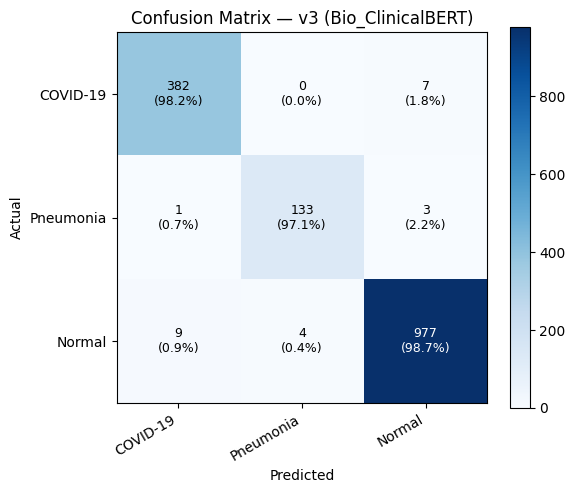


  Learned Rule Weights

  COVID cluster  (temp=0.055  imaging=47% / symptoms=53%)
    Imaging:
      ggo_proxy          0.954  ███████████████████
      effusion           0.132  ██
    Symptoms:
      fever              0.612  ████████████
      dry_cough          0.696  █████████████
      dyspnea            0.437  ████████
      fatigue            0.237  ████

  PNEUMONIA cluster  (temp=0.034  imaging=50% / symptoms=50%)
    Imaging:
      consolidation      0.936  ██████████████████
      infiltration       0.062  █
      edema              0.070  █
    Symptoms:
      fever              0.361  ███████
      chest_pain         0.502  ██████████
      productive_cough   0.905  ██████████████████


In [11]:
# ════════════════════════════════════════════════════════════════
# KERNEL 11 — Evaluate
# ════════════════════════════════════════════════════════════════
import torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from torch.utils.data import DataLoader

reasoning_model.load_state_dict(
    torch.load(REASONING_CHECKPOINT, map_location=device, weights_only=True)
)
reasoning_model.eval()

test_loader = DataLoader(test_sym_ds, batch_size=128, shuffle=False, num_workers=0)
all_preds, all_labels_test = [], []
with torch.no_grad():
    for cnn_feats, sym_vecs, labels in test_loader:
        probs, _ = reasoning_model(cnn_feats.to(device), sym_vecs.to(device))
        all_preds.extend(probs.argmax(1).cpu().tolist())
        all_labels_test.extend(labels.tolist())

print("="*60)
print("  Test Set Evaluation")
print("="*60)
print(classification_report(all_labels_test, all_preds, target_names=DISEASE_NAMES, digits=4))

cm = confusion_matrix(all_labels_test, all_preds)
print("Confusion Matrix:")
print(f"  {'':>14}", "  ".join(f"{n:>12}" for n in DISEASE_NAMES))
for i, row in enumerate(cm):
    row_total = row.sum()
    print(f"  {DISEASE_NAMES[i]:>14}", end="")
    for v in row:
        pct = 100*v/row_total if row_total > 0 else 0
        print(f"  {v:>6} ({pct:4.1f}%)", end="")
    print()

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(DISEASE_NAMES, rotation=30, ha="right")
ax.set_yticklabels(DISEASE_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — v3 (Bio_ClinicalBERT)")
for i in range(3):
    for j in range(3):
        pct = 100*cm[i,j]/cm[i].sum() if cm[i].sum() > 0 else 0
        ax.text(j, i, f"{cm[i,j]}\n({pct:.1f}%)", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix_v3.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("  Learned Rule Weights")
print("="*60)
reasoning_model.describe_learned_rules()

In [22]:
# ════════════════════════════════════════════════════════════════
# KERNEL 12 — Full Pipeline: image + text → diagnostic report
# ════════════════════════════════════════════════════════════════
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

SYMPTOM_NAMES = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]

def compute_calibrated_confidence(probs, explanation, cnn_features):
    """
    Calibration based purely on model outputs — no manual tuning.
    confidence = winning_hypothesis * separation
    Both are directly proportional to what the model learned.
    """
    p        = probs.tolist()
    pred_idx = int(probs.argmax())
    raw_conf = p[pred_idx]

    hs     = explanation["hypothesis_scores"]
    scores = [hs["covid"].mean().item(),
              hs["pneumonia"].mean().item(),
              hs["normal"].mean().item()]
    sorted_s   = sorted(scores, reverse=True)
    winning    = scores[pred_idx]
    separation = sorted_s[0] - sorted_s[1]

    # winning * separation:
    # High winning + high separation = confident (e.g. clear COVID: 0.978 * 0.26 = 0.25... wait)
    # Use sqrt to avoid too much compression
    overall  = winning ** 0.5 * separation ** 0.3
    cal_conf = overall
    scaled   = [round(pi * overall, 4) for pi in p]

    tier = (
        "HIGH    — strong evidence"                              if cal_conf >= 0.45 else
        "MODERATE — some evidence, physician review recommended" if cal_conf >= 0.28 else
        "LOW     — weak evidence, further investigation needed"  if cal_conf >= 0.15 else
        "VERY LOW — insufficient evidence"
    )

    return {
        "raw_confidence":        round(raw_conf, 4),
        "calibrated_confidence": round(cal_conf, 4),
        "scaled_probs":          scaled,
        "overall_factor":        round(overall, 3),
        "winning_hypothesis":    round(winning, 3),
        "separation":            round(separation, 3),
        "tier":                  tier,
        "hypothesis_scores":     scores,
    }


def resolve_prediction(probs, confidence_info):
    is_low = confidence_info["tier"].startswith("LOW") or confidence_info["tier"].startswith("VERY")
    if is_low:
        hs_t = torch.tensor(confidence_info["hypothesis_scores"], dtype=torch.float32)
        soft = torch.softmax(hs_t * 3.0, dim=0)
        return int(soft.argmax()), soft.tolist(), True
    return int(probs.argmax()), probs.tolist(), False


def run_pipeline(image_path, patient_text, verbose=True):
    # Step 1: CNN findings
    img_tensor = val_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    cnn_model.eval()
    with torch.no_grad():
        all_14 = torch.sigmoid(cnn_model(img_tensor)).squeeze()
    cnn_features = all_14[FINDING_ORDER].unsqueeze(0)

    if verbose:
        print("── CNN Findings ──────────────────────────")
        for name, idx in FINDING_INDICES.items():
            val = all_14[idx].item()
            print(f"  {name:<22} {val:.3f}  {'█'*int(val*20)}")

    # Step 2: ClinicalBERT — 6-dim symptom extraction
    sym_tensor = extract_symptoms_bert(patient_text, bert_model, bert_tokenizer, device).unsqueeze(0).to(device)

    if verbose:
        print("\n── Symptom Extraction (Bio_ClinicalBERT) ─")
        sym_vals = sym_tensor.squeeze().cpu().tolist()
        for name, val in zip(SYMPTOM_NAMES, sym_vals):
            print(f"  {name:<20} {val:.3f}  {'█'*int(val*20)}")

    # Step 3: Reasoning layer
    reasoning_model.eval()
    with torch.no_grad():
        probs, explanation = reasoning_model(cnn_features, sym_tensor)
    probs = probs.squeeze().cpu()

    if verbose:
        print("\n── Modality Balance ──────────────────────")
        for name in ["covid", "pneumonia"]:
            b = explanation["imaging_balance"][name]
            print(f"  {name.upper():<12} imaging={b*100:.0f}%  {'█'*int(b*20)}{'░'*int((1-b)*20)}  symptoms={(1-b)*100:.0f}%")
        print("\n── Hypothesis Scores ─────────────────────")
        for k, v in explanation["hypothesis_scores"].items():
            score = v.mean().item()
            print(f"  {k:<12} {score:.3f}  {'█'*int(score*20)}")

    # Step 4: Calibrate
    explanation_cpu = {
        "hypothesis_scores": {k: v.cpu() for k, v in explanation["hypothesis_scores"].items()},
        "covid_activations":    {"cnn": explanation["covid_activations"]["cnn"].cpu(),
                                 "sym": explanation["covid_activations"]["sym"].cpu()},
        "pneumonia_activations":{"cnn": explanation["pneumonia_activations"]["cnn"].cpu(),
                                 "sym": explanation["pneumonia_activations"]["sym"].cpu()},
        "imaging_balance": explanation["imaging_balance"],
    }
    confidence_info = compute_calibrated_confidence(probs, explanation_cpu, cnn_features.cpu())
    final_pred_idx, final_probs, used_fallback = resolve_prediction(probs, confidence_info)

    if verbose:
        print("\n── Calibrated Confidence ─────────────────")
        print(f"  Winning hypothesis  : {confidence_info['winning_hypothesis']:.3f}")
        print(f"  Separation          : {confidence_info['separation']:.3f}")
        print(f"  Calibrated conf     : {confidence_info['calibrated_confidence']:.1%}")
        print(f"  Tier                : {confidence_info['tier']}")
        if used_fallback: print(f"  ⚠️  OOD — using hypothesis scores directly")

    hs       = explanation_cpu["hypothesis_scores"]
    disp     = confidence_info["scaled_probs"]
    pred_name = DISEASE_NAMES[final_pred_idx]

    report = f"""
╔══════════════════════════════════════════════════════════════╗
║          DIAGNOSTIC REPORT  (AI decision-support tool)       ║
╚══════════════════════════════════════════════════════════════╝

  PRIMARY FINDING    :  {pred_name}
  CALIBRATED CONF    :  {confidence_info['calibrated_confidence']:.1%}   (raw: {confidence_info['raw_confidence']:.1%})
  EVIDENCE TIER      :  {confidence_info['tier']}

──────────────────────────────────────────────────────────────
  PATIENT SAID       :  "{patient_text}"
──────────────────────────────────────────────────────────────
  NEUROSYMBOLIC REASONING TRACE
──────────────────────────────────────────────────────────────
  COVID-19  hypothesis  :  {hs['covid'].mean().item():.3f}
  Pneumonia hypothesis  :  {hs['pneumonia'].mean().item():.3f}
  Normal    hypothesis  :  {hs['normal'].mean().item():.3f}

──────────────────────────────────────────────────────────────
  DIFFERENTIAL DIAGNOSIS  (calibrated)
──────────────────────────────────────────────────────────────
  {DISEASE_NAMES[0]:<16}  {disp[0]:.1%}
  {DISEASE_NAMES[1]:<16}  {disp[1]:.1%}
  {DISEASE_NAMES[2]:<16}  {disp[2]:.1%}

  ⚠ Clinical decision-support only. Physician review required.
══════════════════════════════════════════════════════════════"""
    if verbose: print(report)

    return {
        "prediction":             pred_name,
        "calibrated_confidence":  confidence_info["calibrated_confidence"],
        "confidence_tier":        confidence_info["tier"],
        "scaled_probabilities":   dict(zip(DISEASE_NAMES, disp)),
        "hypothesis_scores":      {k: round(v.mean().item(),3) for k,v in hs.items()},
        "used_fallback":          used_fallback,
    }


# ── Safety checks ──────────────────────────────────────────────
assert cnn_model       is not None, "Run Kernel 3 first"
assert bert_model      is not None, "Run Kernel 5 first"
assert reasoning_model is not None, "Run Kernel 10 first"
print("✅ All models loaded, running pipeline...\n")

# ── CHANGE THESE ───────────────────────────────────────────────
TEST_IMAGE_PATH = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset\COVID\images\COVID-6.png"
TEST_TEXT       = "Been coughing for weeks now, losing weight rapidly, drenched in sweat every night, and running a low-grade fever every evening. Completely exhausted all the time."

result = run_pipeline(TEST_IMAGE_PATH, TEST_TEXT)
print(f"\n{'='*50}")
print(f"  Prediction        : {result['prediction']}")
print(f"  Calibrated conf   : {result['calibrated_confidence']:.1%}")
print(f"  Tier              : {result['confidence_tier']}")
print(f"  Hypothesis scores : {result['hypothesis_scores']}")
print(f"  OOD fallback      : {result['used_fallback']}")
print(f"\n  Scaled Probabilities:")
for disease, prob in result['scaled_probabilities'].items():
    bar = '█' * int(prob*30)
    print(f"    {disease:<16} {prob:.4f}  {bar}")

✅ All models loaded, running pipeline...

── CNN Findings ──────────────────────────
  consolidation          0.106  ██
  edema                  0.092  █
  effusion               0.048  
  infiltration           0.222  ████
  cardiomegaly           0.060  █
  ggo_proxy              0.907  ██████████████████

── Symptom Extraction (Bio_ClinicalBERT) ─
  fever                0.983  ███████████████████
  dry_cough            0.022  
  dyspnea              0.015  
  fatigue              0.989  ███████████████████
  chest_pain           0.011  
  productive_cough     0.009  

── Modality Balance ──────────────────────
  COVID        imaging=47%  █████████░░░░░░░░░░  symptoms=53%
  PNEUMONIA    imaging=50%  ██████████░░░░░░░░░  symptoms=50%

── Hypothesis Scores ─────────────────────
  covid        0.980  ███████████████████
  pneumonia    0.467  █████████
  normal       0.432  ████████

── Calibrated Confidence ─────────────────
  Winning hypothesis  : 0.980
  Separation          : 0.513
  

Generating COVID explanation...
✅ Saved → explanation_covid.png


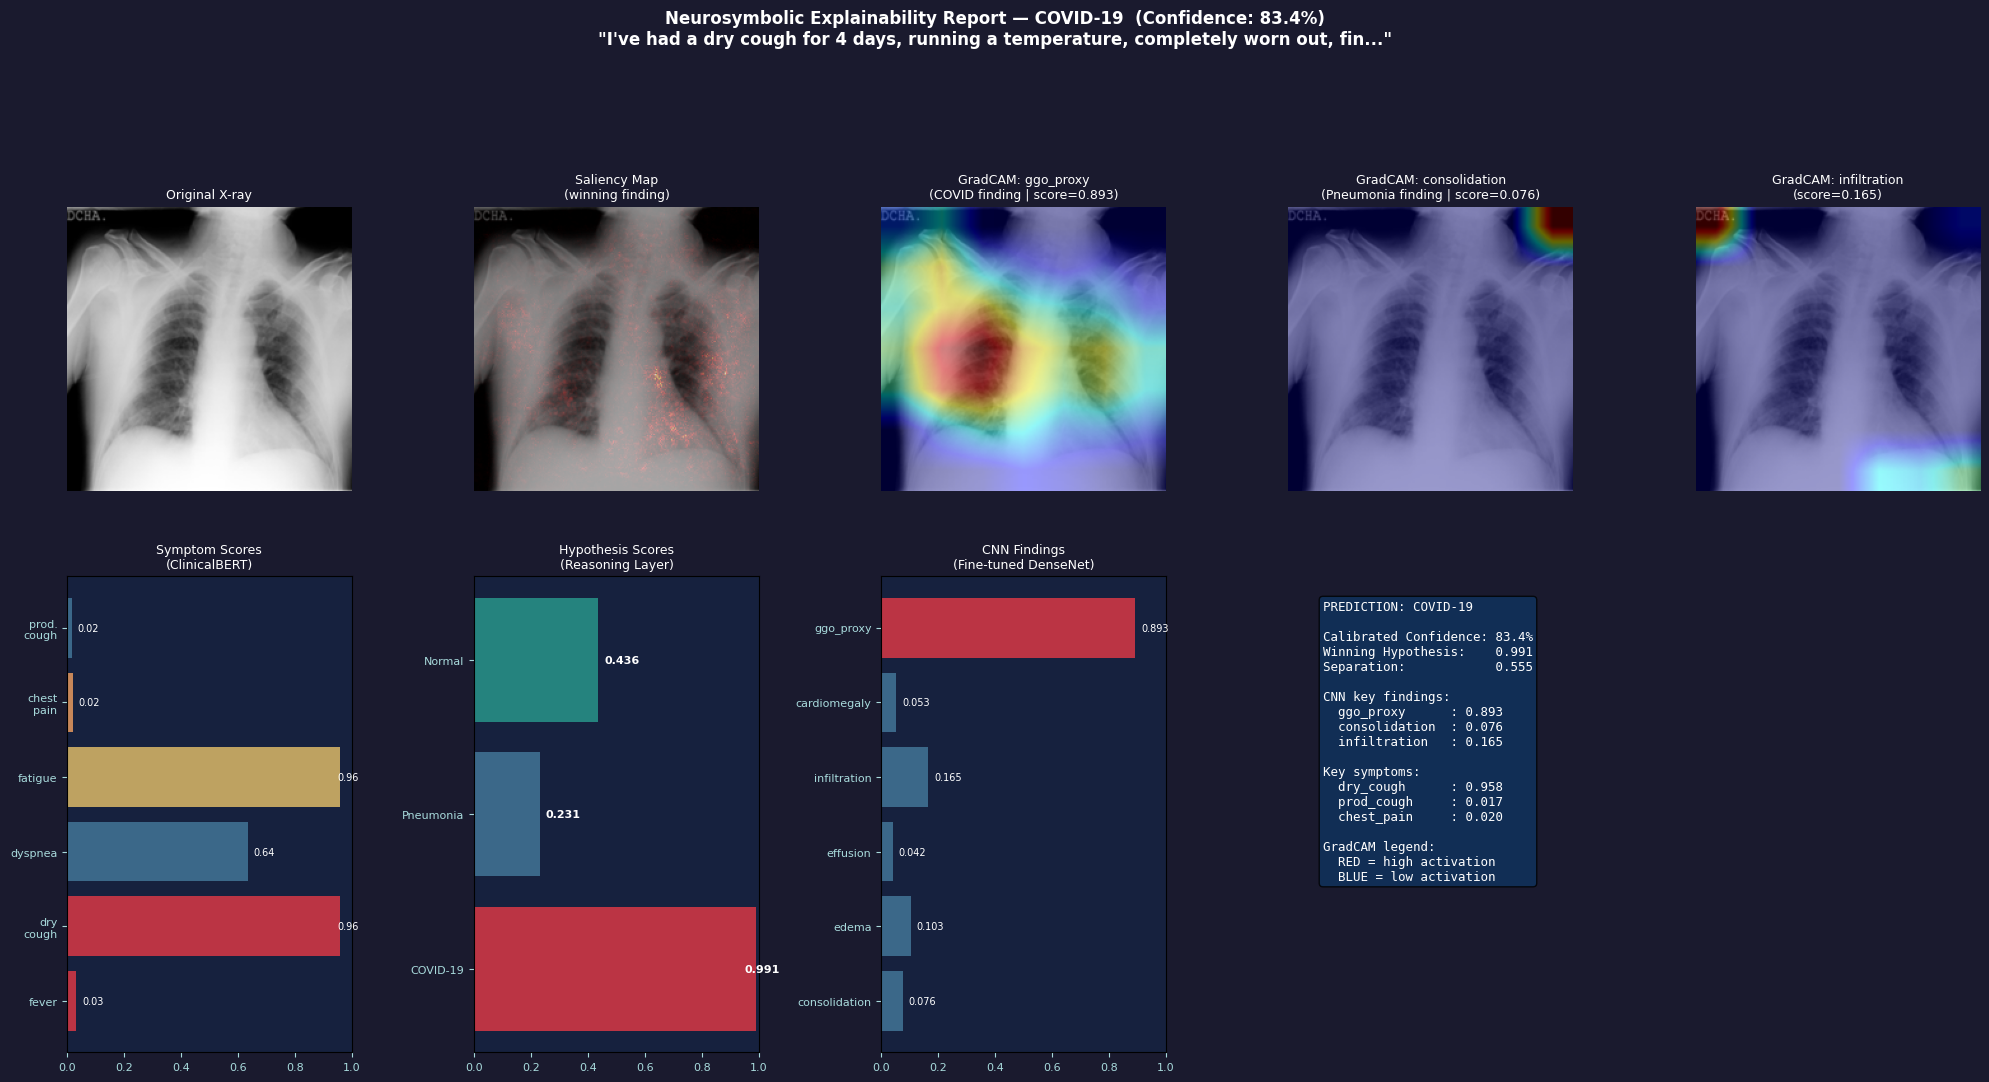


Generating Pneumonia explanation...
✅ Saved → explanation_pneumonia.png


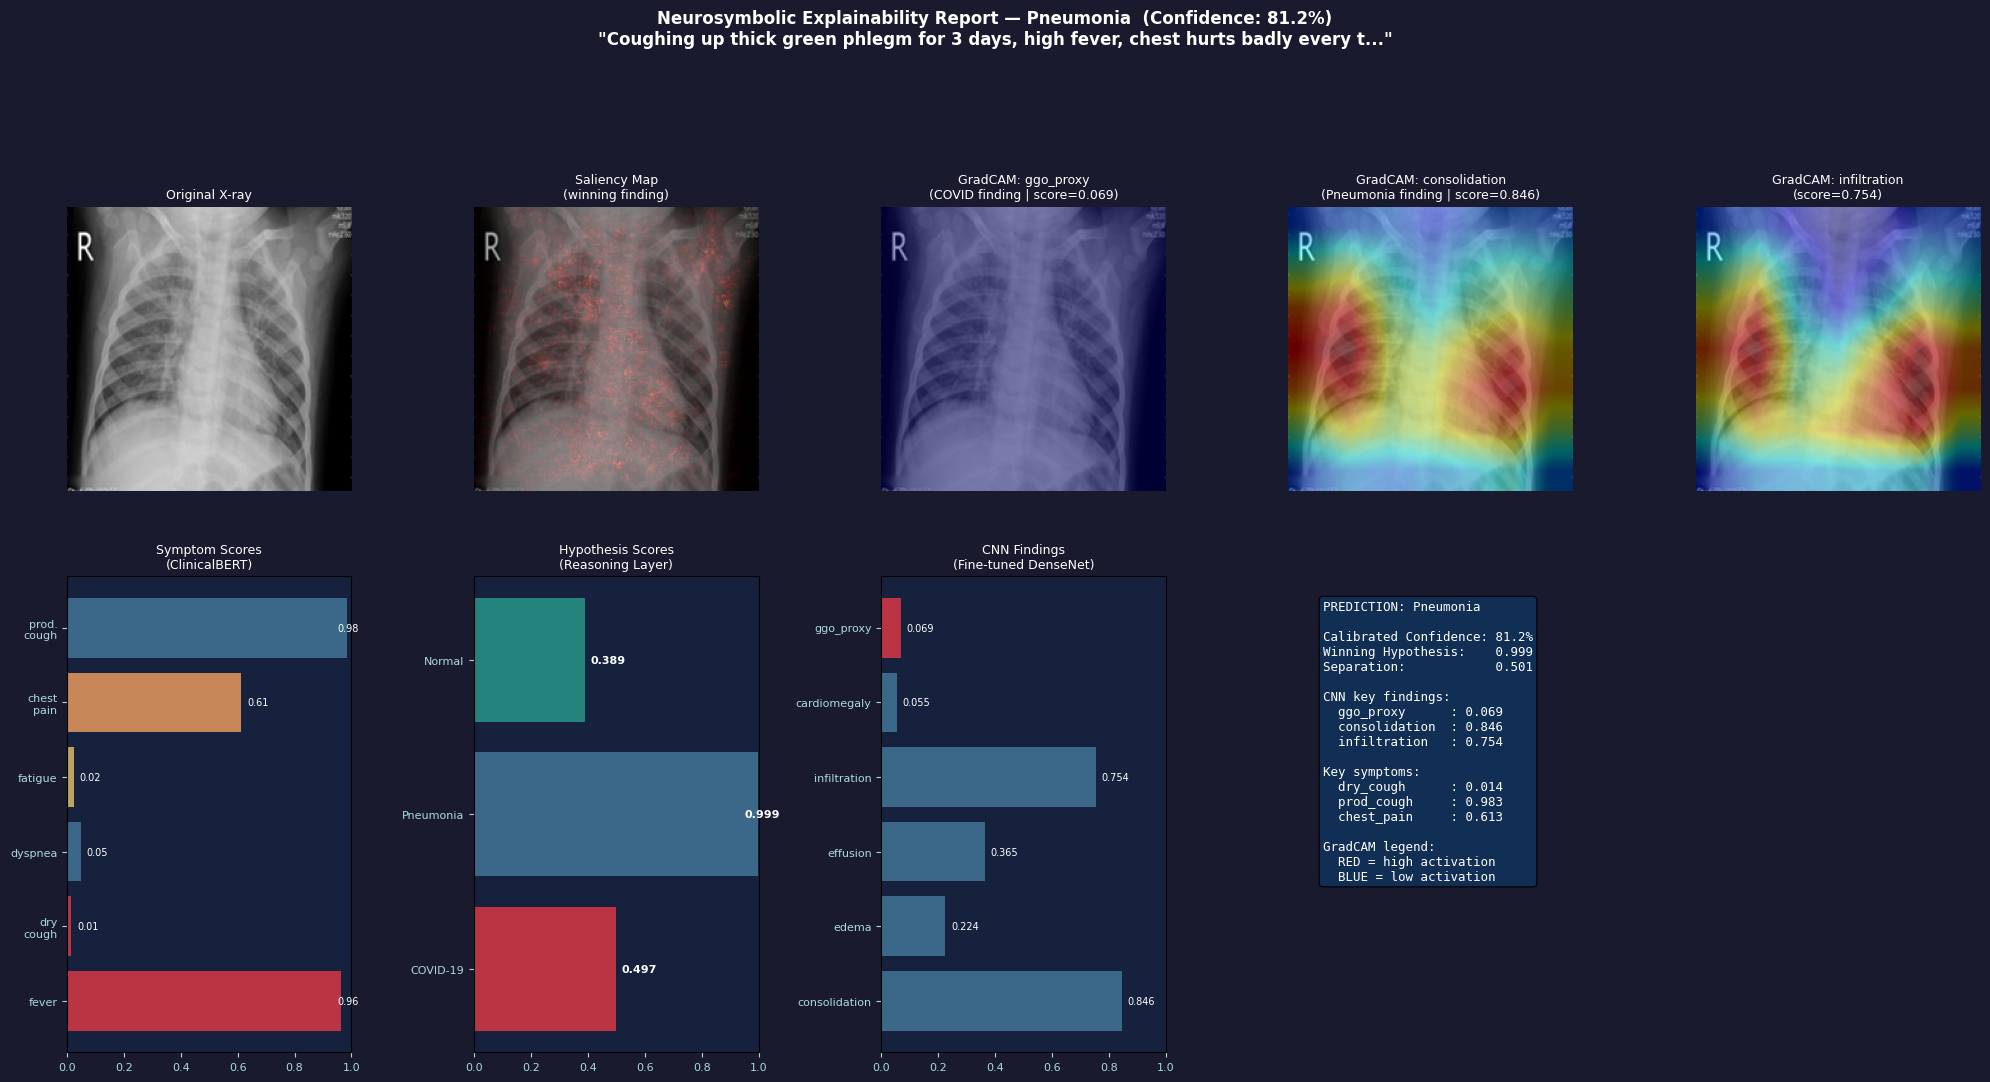


Generating Normal explanation...
✅ Saved → explanation_normal.png


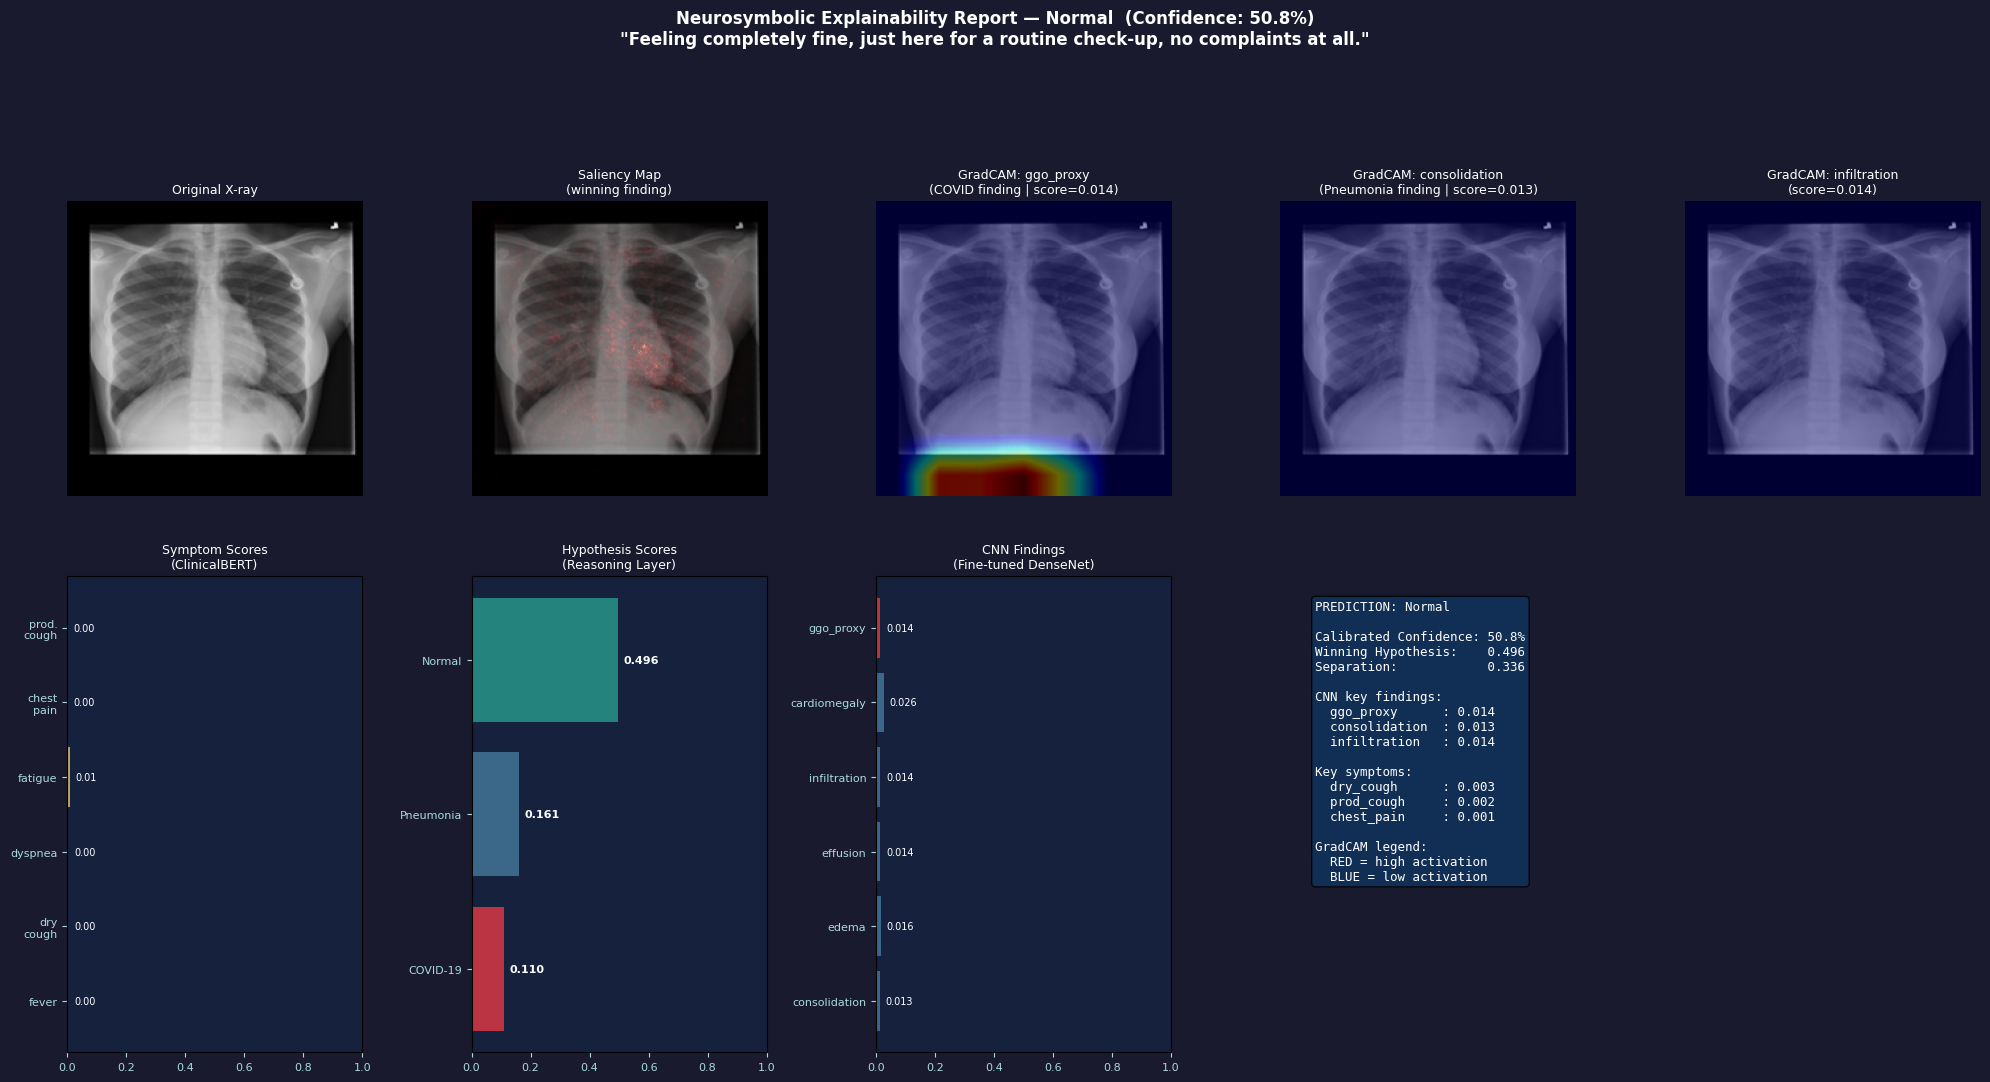


✅ All explanations generated.
   explanation_covid.png
   explanation_pneumonia.png
   explanation_normal.png


In [21]:
# ════════════════════════════════════════════════════════════════
# KERNEL 13 — GradCAM + Saliency Maps
# Shows WHICH regions of the X-ray drove each CNN finding
#
# Produces for each image:
#   1. Original X-ray
#   2. Saliency map (gradient w.r.t. input)
#   3. GradCAM for ggo_proxy     (COVID finding)
#   4. GradCAM for consolidation  (Pneumonia finding)
#   5. GradCAM for infiltration   (shared finding)
#   6. Combined overlay
# ════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import cv2
import os

# ── GradCAM implementation ─────────────────────────────────────
class GradCAM:
    """
    GradCAM for DenseNet-121.
    Hooks into the last dense block to capture gradients and activations.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image_tensor, target_class_idx):
        """
        Generate GradCAM heatmap for a specific output neuron.

        Args:
            image_tensor  : (1, 3, H, W) preprocessed image
            target_class_idx : which CNN output to explain (e.g. 12 for ggo_proxy)

        Returns:
            heatmap (H, W) numpy array, values in [0, 1]
        """
        self.model.eval()
        image_tensor = image_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(image_tensor)  # (1, 14)
        self.model.zero_grad()

        # Backward pass on specific output neuron
        output[0, target_class_idx].backward()

        # Global average pooling of gradients
        pooled_grads = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

        # Weight activations by gradients
        weighted = (pooled_grads * self.activations).sum(dim=1).squeeze()  # (H, W)

        # ReLU — only positive contributions
        heatmap = torch.relu(weighted).cpu().numpy()

        # Normalise to [0, 1]
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap


# ── Saliency map implementation ────────────────────────────────
def compute_saliency(model, image_tensor, target_class_idx):
    """
    Vanilla gradient saliency map.
    Shows which input pixels most affect the target output.

    Returns:
        saliency (H, W) numpy array, values in [0, 1]
    """
    model.eval()
    img = image_tensor.clone().requires_grad_(True)

    output = model(img)
    model.zero_grad()
    output[0, target_class_idx].backward()

    # Take max across colour channels
    saliency = img.grad.data.abs().squeeze()
    saliency = saliency.max(dim=0)[0].cpu().numpy()

    # Normalise
    if saliency.max() > 0:
        saliency = saliency / saliency.max()

    return saliency


# ── Overlay helper ─────────────────────────────────────────────
def overlay_heatmap(original_np, heatmap, colormap=cv2.COLORMAP_JET, alpha=0.4):
    """
    Overlay a heatmap on the original image.

    Args:
        original_np : (H, W, 3) uint8 RGB image
        heatmap     : (H, W) float array in [0, 1]
        alpha       : blending factor

    Returns:
        overlaid (H, W, 3) uint8 RGB image
    """
    h, w = original_np.shape[:2]

    # Resize heatmap to match image
    heatmap_resized = cv2.resize(heatmap, (w, h))

    # Apply colormap
    heatmap_uint8  = np.uint8(255 * heatmap_resized)
    heatmap_colour = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_rgb    = cv2.cvtColor(heatmap_colour, cv2.COLOR_BGR2RGB)

    # Blend
    overlaid = (alpha * heatmap_rgb + (1-alpha) * original_np).astype(np.uint8)
    return overlaid


# ── Main visualization function ────────────────────────────────
def visualize_explanations(
    image_path,
    patient_text,
    cnn_model,
    bert_model,
    bert_tokenizer,
    reasoning_model,
    device,
    save_path=None
):
    """
    Generate full GradCAM + saliency explanation for one case.

    Shows:
      Row 1: Original | Saliency | GradCAM ggo_proxy | GradCAM consolidation | GradCAM infiltration
      Row 2: Symptom bar chart | Hypothesis scores | Finding probabilities
    """

    # ── Load and preprocess image ──────────────────────────────
    val_transform = T.Compose([
        T.Resize((224, 224)),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ])
    pil_img    = Image.open(image_path).convert("RGB").resize((224, 224))
    original   = np.array(pil_img)
    img_tensor = val_transform(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    # ── Run CNN ────────────────────────────────────────────────
    cnn_model.eval()

    # Hook into last dense block for GradCAM
    # DenseNet-121: features.denseblock4 → features.norm5
    target_layer = cnn_model.features.denseblock4
    gradcam      = GradCAM(cnn_model, target_layer)

    with torch.no_grad():
        all_14 = torch.sigmoid(cnn_model(img_tensor)).squeeze()

    cnn_findings = {
        "consolidation":  all_14[2].item(),
        "edema":          all_14[3].item(),
        "effusion":       all_14[4].item(),
        "infiltration":   all_14[8].item(),
        "cardiomegaly":   all_14[1].item(),
        "ggo_proxy":      all_14[12].item(),
    }

    # ── Generate GradCAMs for key findings ─────────────────────
    # Need gradients → re-run with grad enabled
    img_grad = img_tensor.clone().detach().requires_grad_(False)

    cam_ggo           = gradcam.generate(img_tensor.clone(), target_class_idx=12)
    cam_consolidation = gradcam.generate(img_tensor.clone(), target_class_idx=2)
    cam_infiltration  = gradcam.generate(img_tensor.clone(), target_class_idx=8)
    cam_effusion      = gradcam.generate(img_tensor.clone(), target_class_idx=4)

    # ── Saliency for winning finding ───────────────────────────
    winning_finding_idx = max(FINDING_INDICES.values(),
                              key=lambda idx: all_14[idx].item())
    saliency = compute_saliency(cnn_model, img_tensor.clone(), winning_finding_idx)

    # ── Run BERT ───────────────────────────────────────────────
    sym_tensor = extract_symptoms_bert(
        patient_text, bert_model, bert_tokenizer, device
    ).unsqueeze(0).to(device)
    sym_vals = sym_tensor.squeeze().cpu().tolist()

    # ── Run reasoning layer ────────────────────────────────────
    cnn_features = all_14[FINDING_ORDER].unsqueeze(0)
    reasoning_model.eval()
    with torch.no_grad():
        probs, explanation = reasoning_model(cnn_features, sym_tensor)
    probs = probs.squeeze().cpu()
    pred_idx  = int(probs.argmax())
    pred_name = DISEASE_NAMES[pred_idx]

    hs = explanation["hypothesis_scores"]
    hypothesis_scores = {
        "COVID-19":  hs["covid"].mean().item(),
        "Pneumonia": hs["pneumonia"].mean().item(),
        "Normal":    hs["normal"].mean().item(),
    }

    # ── Calibrated confidence ──────────────────────────────────
    scores   = list(hypothesis_scores.values())
    sorted_s = sorted(scores, reverse=True)
    winning  = scores[pred_idx]
    sep      = sorted_s[0] - sorted_s[1]
    cal_conf = winning ** 0.5 * sep ** 0.3

    # ── Plot ───────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 11))
    fig.patch.set_facecolor("#1a1a2e")

    title_color   = "white"
    label_color   = "#a8dadc"
    bar_covid     = "#e63946"
    bar_pneumonia = "#457b9d"
    bar_normal    = "#2a9d8f"

    fig.suptitle(
        f"Neurosymbolic Explainability Report — {pred_name}  "
        f"(Confidence: {cal_conf:.1%})\n\"{patient_text[:80]}{'...' if len(patient_text)>80 else ''}\"",
        fontsize=12, color=title_color, y=0.98, fontweight="bold"
    )

    # ── Row 1: Image visualizations ────────────────────────────
    ax1 = fig.add_subplot(2, 5, 1)
    ax1.imshow(original)
    ax1.set_title("Original X-ray", color=title_color, fontsize=9)
    ax1.axis("off")

    ax2 = fig.add_subplot(2, 5, 2)
    ax2.imshow(original, cmap="gray")
    sal_overlay = overlay_heatmap(original, saliency, cv2.COLORMAP_HOT, alpha=0.5)
    ax2.imshow(sal_overlay, alpha=0.7)
    ax2.set_title(f"Saliency Map\n(winning finding)", color=title_color, fontsize=9)
    ax2.axis("off")

    ax3 = fig.add_subplot(2, 5, 3)
    overlay_ggo = overlay_heatmap(original, cam_ggo, cv2.COLORMAP_JET)
    ax3.imshow(overlay_ggo)
    ax3.set_title(f"GradCAM: ggo_proxy\n(COVID finding | score={cnn_findings['ggo_proxy']:.3f})",
                  color=title_color, fontsize=9)
    ax3.axis("off")

    ax4 = fig.add_subplot(2, 5, 4)
    overlay_con = overlay_heatmap(original, cam_consolidation, cv2.COLORMAP_JET)
    ax4.imshow(overlay_con)
    ax4.set_title(f"GradCAM: consolidation\n(Pneumonia finding | score={cnn_findings['consolidation']:.3f})",
                  color=title_color, fontsize=9)
    ax4.axis("off")

    ax5 = fig.add_subplot(2, 5, 5)
    overlay_inf = overlay_heatmap(original, cam_infiltration, cv2.COLORMAP_JET)
    ax5.imshow(overlay_inf)
    ax5.set_title(f"GradCAM: infiltration\n(score={cnn_findings['infiltration']:.3f})",
                  color=title_color, fontsize=9)
    ax5.axis("off")

    # ── Row 2: Charts ──────────────────────────────────────────
    sym_names_display = ["fever", "dry\ncough", "dyspnea", "fatigue", "chest\npain", "prod.\ncough"]
    sym_colors = ["#e63946","#e63946","#457b9d","#e9c46a","#f4a261","#457b9d"]

    ax6 = fig.add_subplot(2, 5, 6)
    bars = ax6.barh(sym_names_display, sym_vals, color=sym_colors, alpha=0.8)
    ax6.set_xlim(0, 1)
    ax6.set_title("Symptom Scores\n(ClinicalBERT)", color=title_color, fontsize=9)
    ax6.tick_params(colors=label_color, labelsize=8)
    ax6.set_facecolor("#16213e")
    for bar, val in zip(bars, sym_vals):
        ax6.text(min(val+0.02, 0.95), bar.get_y()+bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=7, color="white")

    ax7 = fig.add_subplot(2, 5, 7)
    hyp_names  = list(hypothesis_scores.keys())
    hyp_values = list(hypothesis_scores.values())
    hyp_colors = [bar_covid, bar_pneumonia, bar_normal]
    bars2 = ax7.barh(hyp_names, hyp_values, color=hyp_colors, alpha=0.8)
    ax7.set_xlim(0, 1)
    ax7.set_title("Hypothesis Scores\n(Reasoning Layer)", color=title_color, fontsize=9)
    ax7.tick_params(colors=label_color, labelsize=8)
    ax7.set_facecolor("#16213e")
    for bar, val in zip(bars2, hyp_values):
        ax7.text(min(val+0.02, 0.95), bar.get_y()+bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8, color="white", fontweight="bold")

    ax8 = fig.add_subplot(2, 5, 8)
    finding_names  = list(cnn_findings.keys())
    finding_values = list(cnn_findings.values())
    finding_colors = ["#457b9d","#457b9d","#457b9d","#457b9d","#457b9d","#e63946"]
    finding_colors[finding_names.index("ggo_proxy")] = "#e63946"
    finding_colors[finding_names.index("consolidation")] = "#457b9d"
    bars3 = ax8.barh(finding_names, finding_values, color=finding_colors, alpha=0.8)
    ax8.set_xlim(0, 1)
    ax8.set_title("CNN Findings\n(Fine-tuned DenseNet)", color=title_color, fontsize=9)
    ax8.tick_params(colors=label_color, labelsize=8)
    ax8.set_facecolor("#16213e")
    for bar, val in zip(bars3, finding_values):
        ax8.text(min(val+0.02, 0.95), bar.get_y()+bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=7, color="white")

    # ── Confidence summary box ──────────────────────────────────
    ax9 = fig.add_subplot(2, 5, (9, 10))
    ax9.set_facecolor("#16213e")
    ax9.axis("off")

    summary_text = (
        f"PREDICTION: {pred_name}\n\n"
        f"Calibrated Confidence: {cal_conf:.1%}\n"
        f"Winning Hypothesis:    {winning:.3f}\n"
        f"Separation:            {sep:.3f}\n\n"
        f"CNN key findings:\n"
        f"  ggo_proxy      : {cnn_findings['ggo_proxy']:.3f}\n"
        f"  consolidation  : {cnn_findings['consolidation']:.3f}\n"
        f"  infiltration   : {cnn_findings['infiltration']:.3f}\n\n"
        f"Key symptoms:\n"
        f"  dry_cough      : {sym_vals[1]:.3f}\n"
        f"  prod_cough     : {sym_vals[5]:.3f}\n"
        f"  chest_pain     : {sym_vals[4]:.3f}\n\n"
        f"GradCAM legend:\n"
        f"  RED = high activation\n"
        f"  BLUE = low activation"
    )
    ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
             fontsize=9, color="white", va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#0f3460", alpha=0.8))

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"✅ Saved → {save_path}")

    plt.show()
    return fig


# ════════════════════════════════════════════════════════════════
# Run visualizations
# ════════════════════════════════════════════════════════════════

# Install opencv if needed
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless"])
    import cv2

SYMPTOM_NAMES = ["fever", "dry_cough", "dyspnea", "fatigue", "chest_pain", "productive_cough"]

# ── Test Case 1: COVID ──────────────────────────────────────────
print("Generating COVID explanation...")
fig1 = visualize_explanations(
    image_path   = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset\COVID\images\COVID-145.png",
    patient_text = "I've had a dry cough for 4 days, running a temperature, completely worn out, finding it hard to breathe.",
    cnn_model        = cnn_model,
    bert_model       = bert_model,
    bert_tokenizer   = bert_tokenizer,
    reasoning_model  = reasoning_model,
    device           = device,
    save_path        = "explanation_covid.png",
)

# ── Test Case 2: Pneumonia ──────────────────────────────────────
print("\nGenerating Pneumonia explanation...")
fig2 = visualize_explanations(
    image_path   = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset\Viral Pneumonia\images\Viral Pneumonia-1.png",
    patient_text = "Coughing up thick green phlegm for 3 days, high fever, chest hurts badly every time I breathe in.",
    cnn_model        = cnn_model,
    bert_model       = bert_model,
    bert_tokenizer   = bert_tokenizer,
    reasoning_model  = reasoning_model,
    device           = device,
    save_path        = "explanation_pneumonia.png",
)

# ── Test Case 3: Normal ─────────────────────────────────────────
print("\nGenerating Normal explanation...")
fig3 = visualize_explanations(
    image_path   = r"C:\Users\adhit\Downloads\neurosymbolic\COVID-19_Radiography_Dataset\COVID-19_Radiography_Dataset\Normal\images\Normal-1.png",
    patient_text = "Feeling completely fine, just here for a routine check-up, no complaints at all.",
    cnn_model        = cnn_model,
    bert_model       = bert_model,
    bert_tokenizer   = bert_tokenizer,
    reasoning_model  = reasoning_model,
    device           = device,
    save_path        = "explanation_normal.png",
)

print("\n✅ All explanations generated.")
print("   explanation_covid.png")
print("   explanation_pneumonia.png")
print("   explanation_normal.png")